# Import Libraries

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


# Load Dataset

In [ ]:


from pathlib import Path

DATA_PATH = Path("../data/processed/cleaned_stock_data.csv")

stocks_df = pd.read_csv(DATA_PATH)

stocks_df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,Company Name,Industry,ISIN Code
0,2007-11-27,ADANIPORTS,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619.0,0.3612,Adani Ports and Special Economic Zone Ltd.,SERVICES,INE742F01042
1,2007-11-28,ADANIPORTS,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278.0,0.3172,Adani Ports and Special Economic Zone Ltd.,SERVICES,INE742F01042
2,2007-11-29,ADANIPORTS,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678.0,0.2088,Adani Ports and Special Economic Zone Ltd.,SERVICES,INE742F01042
3,2007-11-30,ADANIPORTS,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913.0,0.2735,Adani Ports and Special Economic Zone Ltd.,SERVICES,INE742F01042
4,2007-12-03,ADANIPORTS,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123.0,0.2741,Adani Ports and Special Economic Zone Ltd.,SERVICES,INE742F01042


# Dataset Overview

In [3]:
stocks_df.shape

(235192, 18)

In [4]:
stocks_df.columns.tolist()

['Date',
 'Symbol',
 'Series',
 'Prev Close',
 'Open',
 'High',
 'Low',
 'Last',
 'Close',
 'VWAP',
 'Volume',
 'Turnover',
 'Trades',
 'Deliverable Volume',
 '%Deliverble',
 'Company Name',
 'Industry',
 'ISIN Code']

In [5]:
stocks_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235192 entries, 0 to 235191
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Date                235192 non-null  str    
 1   Symbol              235192 non-null  str    
 2   Series              235192 non-null  str    
 3   Prev Close          235192 non-null  float64
 4   Open                235192 non-null  float64
 5   High                235192 non-null  float64
 6   Low                 235192 non-null  float64
 7   Last                235192 non-null  float64
 8   Close               235192 non-null  float64
 9   VWAP                235192 non-null  float64
 10  Volume              235192 non-null  int64  
 11  Turnover            235192 non-null  float64
 12  Trades              120344 non-null  float64
 13  Deliverable Volume  219115 non-null  float64
 14  %Deliverble         219115 non-null  float64
 15  Company Name        235192 non-null  str    


In [6]:
stocks_df["Date"] = pd.to_datetime(stocks_df["Date"])

In [7]:
stocks_df["Date"].dtype

dtype('<M8[us]')

In [8]:
stocks_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,235192,2011-05-22 13:18:08.975815,2000-01-03 00:00:00,2006-07-03 00:00:00,2011-08-19 00:00:00,2016-06-24 00:00:00,2021-04-30 00:00:00,NaN
Prev Close,235192.0,1266.196349,0.0,274.3,566.5,1242.2,32861.95,2581.37032
Open,235192.0,1267.759708,8.5,275.0,567.025,1243.3125,33399.95,2585.259609
High,235192.0,1286.58144,9.75,279.5,576.9,1263.0,33480.0,2619.649216
Low,235192.0,1247.488465,8.5,269.6,556.5,1221.65,32468.1,2546.621396
Last,235192.0,1266.388302,9.1,274.4,567.0,1242.9,32849.0,2581.392543
Close,235192.0,1266.554351,9.15,274.35,566.7,1242.4,32861.95,2582.140942
VWAP,235192.0,1267.1323,9.21,274.6975,566.94,1242.6625,32975.24,2582.69998
Volume,235192.0,3045903.28603,3.0,219009.5,1010938.5,3019851.0,481058927.0,7333980.756792
Turnover,235192.0,161013844789483.3125,10470000.0,16128159588750.0,68326029390000.0,186383456571250.0,35643341676765004.0,329808537918688.9375


In [9]:
print("Start Date :", stocks_df["Date"].min())
print("End Date :", stocks_df["Date"].max())

Start Date : 2000-01-03 00:00:00
End Date : 2021-04-30 00:00:00


In [10]:
print("Unique Stocks :", stocks_df["Symbol"].nunique())

Unique Stocks : 49


In [11]:
print("Industries :", stocks_df["Industry"].nunique())

Industries : 13


In [12]:
stocks_df["Industry"].unique()

<StringArray>
[                'SERVICES',           'CONSUMER GOODS',
       'FINANCIAL SERVICES',               'AUTOMOBILE',
                  'TELECOM',                   'ENERGY',
                   'PHARMA',                   'METALS',
 'CEMENT & CEMENT PRODUCTS',                       'IT',
             'CONSTRUCTION', 'FERTILISERS & PESTICIDES',
    'MEDIA & ENTERTAINMENT']
Length: 13, dtype: str

# Missing Value Analysis

In [ ]:


stocks_df.isnull().sum()

Date                       0
Symbol                     0
Series                     0
Prev Close                 0
Open                       0
High                       0
Low                        0
Last                       0
Close                      0
VWAP                       0
Volume                     0
Turnover                   0
Trades                114848
Deliverable Volume     16077
%Deliverble            16077
Company Name               0
Industry                   0
ISIN Code                  0
dtype: int64

In [14]:
missing = pd.DataFrame({
    "Missing Values": stocks_df.isnull().sum(),
    "Percentage": (
        stocks_df.isnull().mean() * 100
    ).round(2)
})

missing.sort_values(
    "Missing Values",
    ascending=False
)

,Missing Values,Percentage
Trades,114848,48.83
Deliverable Volume,16077,6.84
%Deliverble,16077,6.84
Date,0,0.00
Symbol,0,0.00
Series,0,0.00
Low,0,0.00
Prev Close,0,0.00
Open,0,0.00
High,0,0.00


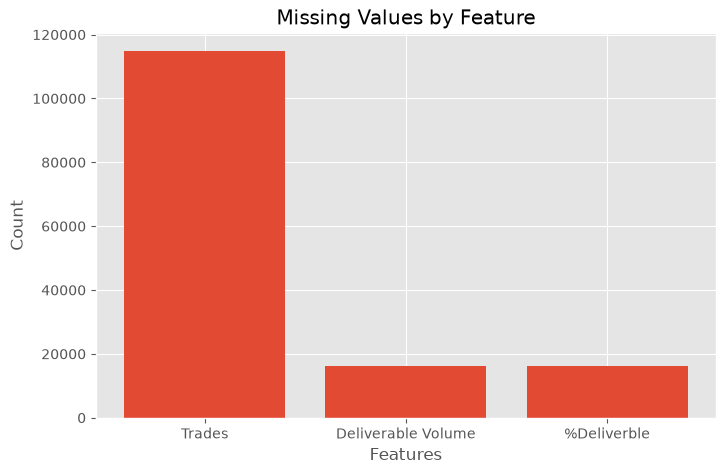

In [16]:
missing = missing[missing["Missing Values"] > 0]

plt.figure(figsize=(8,5))

plt.bar(
    missing.index,
    missing["Missing Values"]
)

plt.xlabel("Features")
plt.title("Missing Values by Feature")
plt.ylabel("Count")
plt.show()

# Univariate Analysis

In [18]:
# Number of Records per Stock

records_per_stock = (stocks_df.groupby("Symbol").size().sort_values(ascending=False))

records_per_stock

Symbol
ASIANPAINT    5306
GRASIM        5306
AXISBANK      5306
BPCL          5306
CIPLA         5306
DRREDDY       5306
HDFC          5306
ZEEL          5306
M&M           5306
ITC           5306
IOC           5306
INFY          5306
ICICIBANK     5306
HINDUNILVR    5306
HINDALCO      5306
HEROMOTOCO    5306
HDFCBANK      5306
WIPRO         5306
TITAN         5306
TATAMOTORS    5306
TATASTEEL     5306
SUNPHARMA     5306
SBIN          5306
RELIANCE      5306
ONGC          5306
VEDL          5305
BRITANNIA     5305
EICHERMOT     5301
HCLTECH       5300
BAJFINANCE    5235
GAIL          4985
INDUSINDBK    4985
SHREECEM      4985
KOTAKBANK     4985
BHARTIARTL    4774
MARUTI        4427
UPL           4287
LT            4184
ULTRACEMCO    4140
TCS           4139
NTPC          4088
JSWSTEEL      3994
TECHM         3635
POWERGRID     3359
ADANIPORTS    3322
BAJAJ-AUTO    3202
BAJAJFINSV    3201
NESTLEIND     2806
COALINDIA     2598
dtype: int64

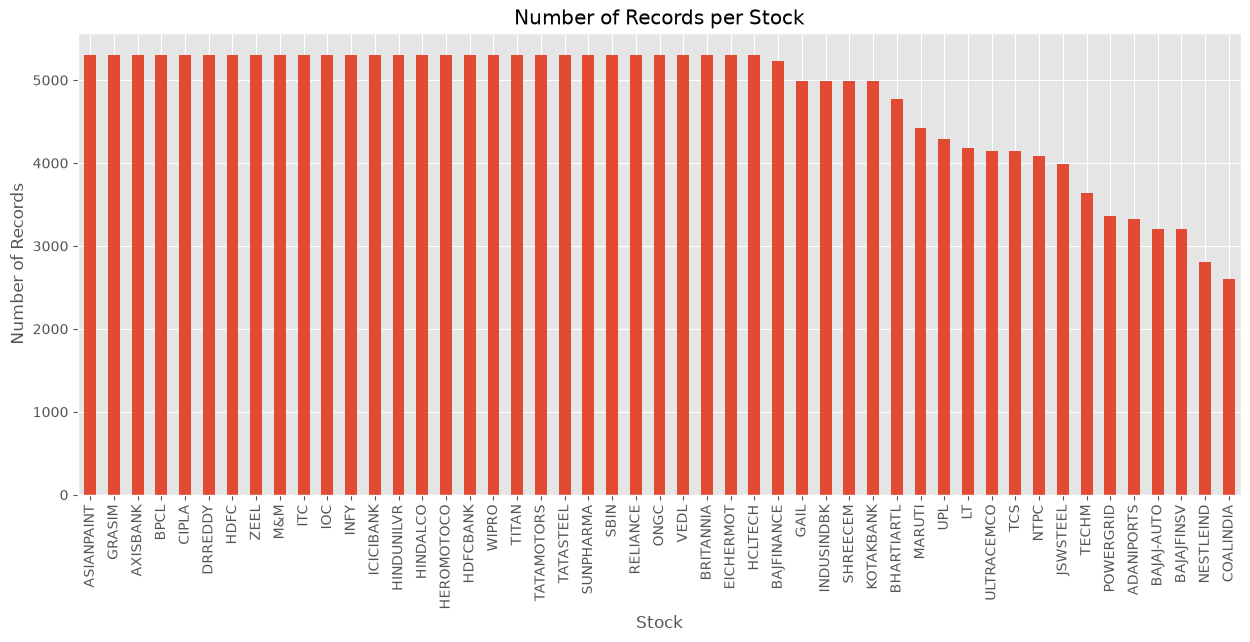

In [19]:
plt.figure(figsize=(15,6))

records_per_stock.plot(kind="bar")

plt.title("Number of Records per Stock")
plt.xlabel("Stock")
plt.ylabel("Number of Records")
plt.xticks(rotation=90)

plt.show()

In [20]:
# Industry Distribution

industry_distribution = stocks_df.groupby("Industry").size().sort_values(ascending=False)

industry_distribution

Industry
FINANCIAL SERVICES          44936
ENERGY                      33656
CONSUMER GOODS              29335
AUTOMOBILE                  28848
IT                          23686
METALS                      22509
PHARMA                      15918
CEMENT & CEMENT PRODUCTS    14431
MEDIA & ENTERTAINMENT        5306
TELECOM                      4774
FERTILISERS & PESTICIDES     4287
CONSTRUCTION                 4184
SERVICES                     3322
dtype: int64

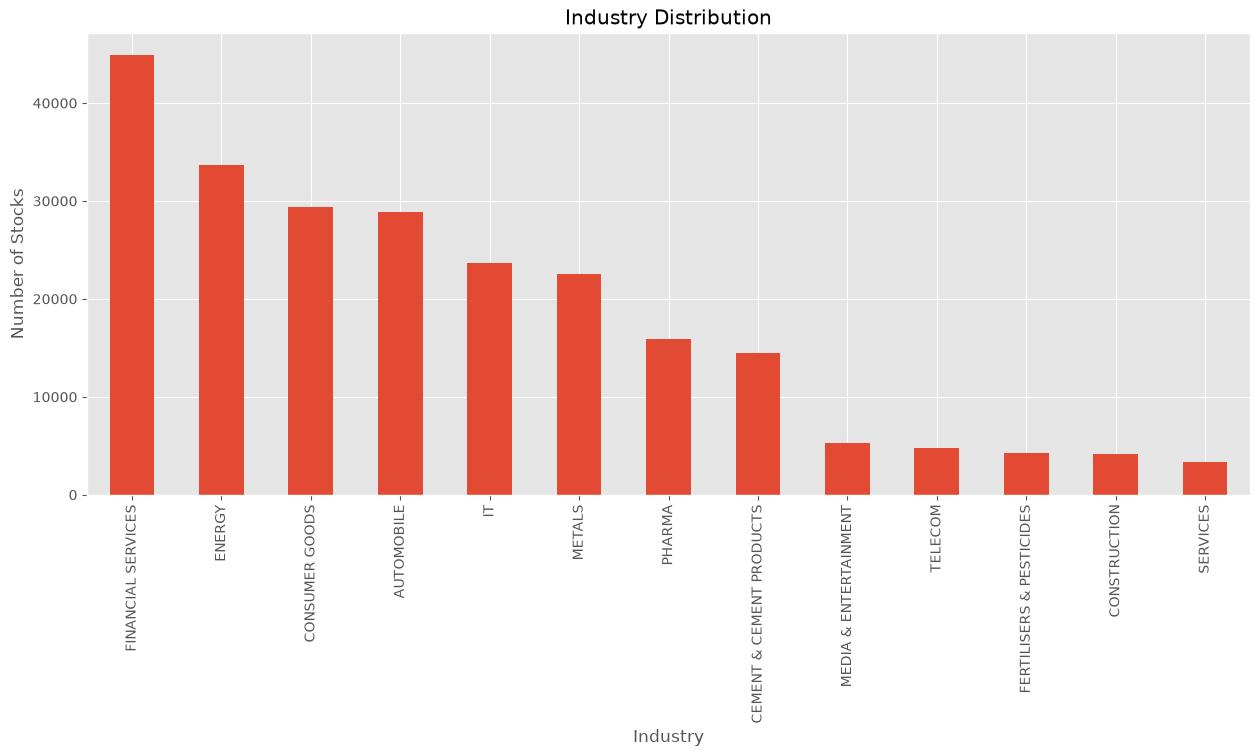

In [21]:
plt.figure(figsize=(15,6))
industry_distribution.plot(kind="bar")

plt.title("Industry Distribution")
plt.xlabel("Industry")
plt.ylabel("Number of Stocks")
plt.xticks(rotation=90)
plt.show()

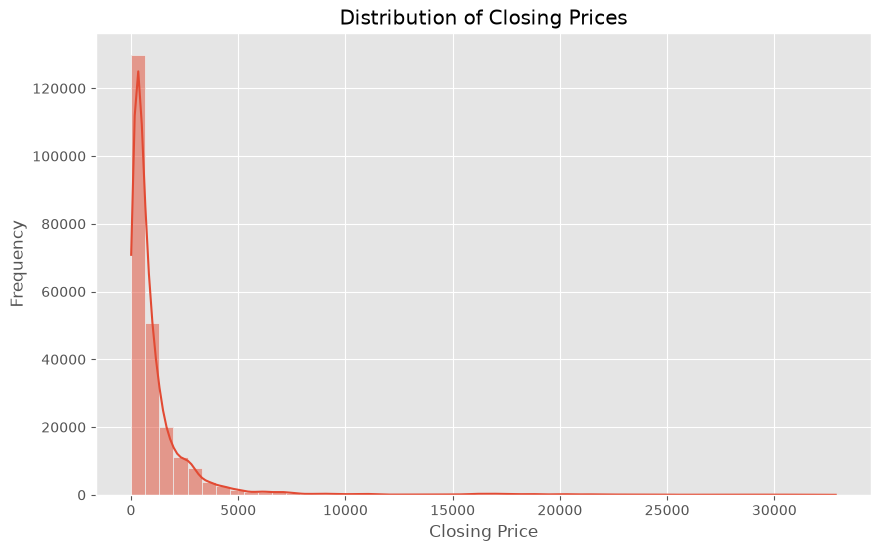

In [29]:
# Closing Price Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    stocks_df["Close"],
    bins=50,
    kde=True,
)

plt.title("Distribution of Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")

plt.show()

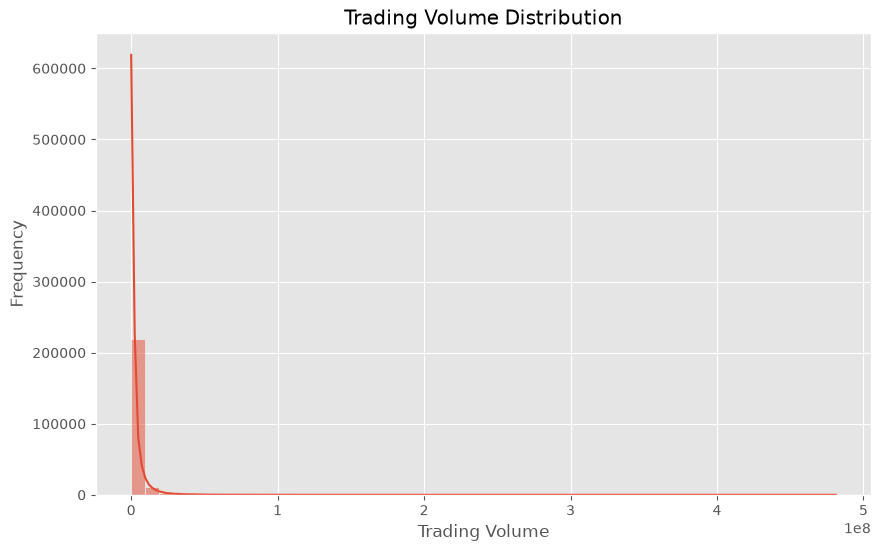

In [34]:
# Trading Volume Distribution

plt.figure(figsize=(10,6))
sns.histplot(stocks_df["Volume"], bins=50, kde=True)
plt.title("Trading Volume Distribution")
plt.xlabel("Trading Volume")
plt.ylabel("Frequency")
plt.show()

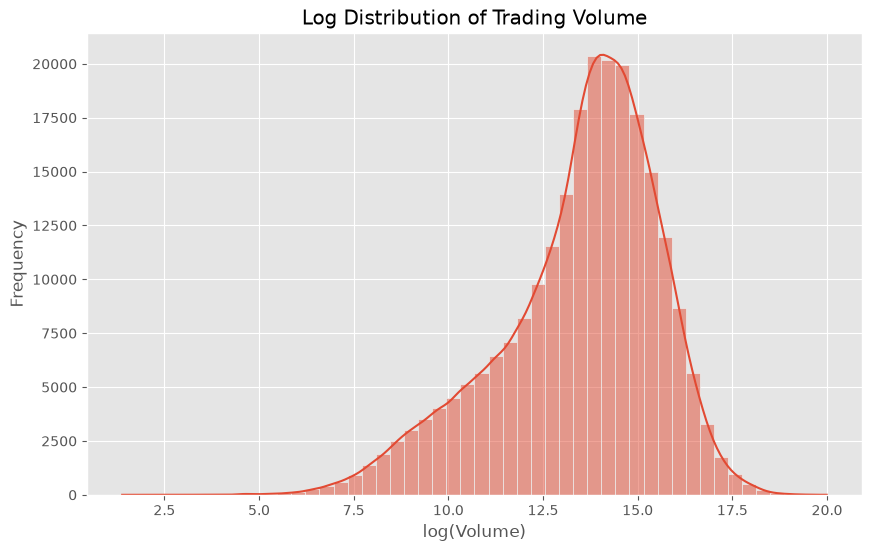

In [36]:
plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(stocks_df["Volume"]),
    bins=50,
    kde=True
)

plt.title("Log Distribution of Trading Volume")
plt.xlabel("log(Volume)")
plt.ylabel("Frequency")

plt.show()

In [38]:
# Create Daily Returns

stocks_df["Daily Return"] = (stocks_df.groupby("Symbol")["Close"].pct_change())

In [39]:
stocks_df[["Symbol","Date","Close","Daily Return"]].head(10)

,Symbol,Date,Close,Daily Return
0,ADANIPORTS,2007-11-27,962.90,NaN
1,ADANIPORTS,2007-11-28,893.90,-0.071659
2,ADANIPORTS,2007-11-29,884.20,-0.010851
3,ADANIPORTS,2007-11-30,921.55,0.042242
4,ADANIPORTS,2007-12-03,969.30,0.051815
5,ADANIPORTS,2007-12-04,1041.45,0.074435
6,ADANIPORTS,2007-12-05,1082.45,0.039368
7,ADANIPORTS,2007-12-06,1081.30,-0.001062
8,ADANIPORTS,2007-12-07,1102.40,0.019514
9,ADANIPORTS,2007-12-10,1075.40,-0.024492


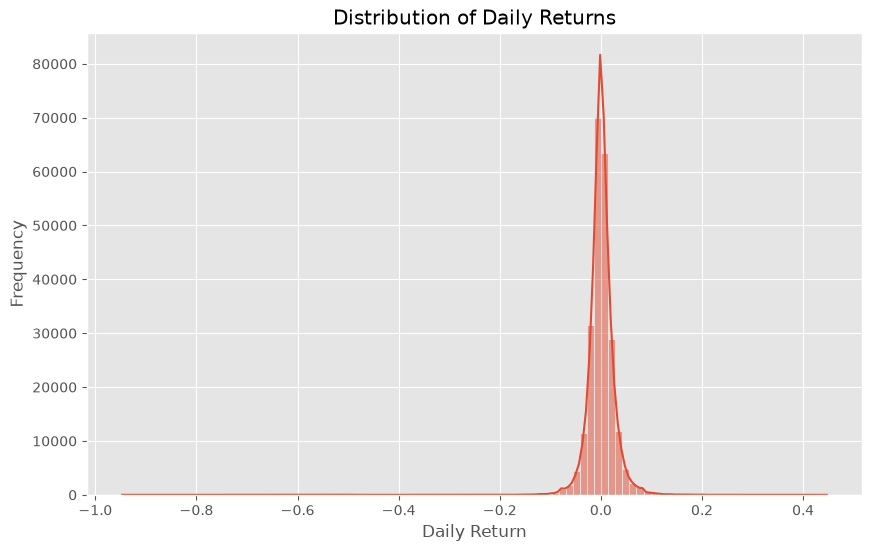

In [40]:
# Distribution of Daily Returns

plt.figure(figsize=(10,6))
sns.histplot(stocks_df["Daily Return"].dropna(), bins=100, kde=True)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [41]:
# Return Statistics
stocks_df["Daily Return"].describe()

count    235143.000000
mean          0.000689
std           0.027252
min          -0.946849
25%          -0.011136
50%           0.000187
75%           0.012197
max           0.446731
Name: Daily Return, dtype: float64

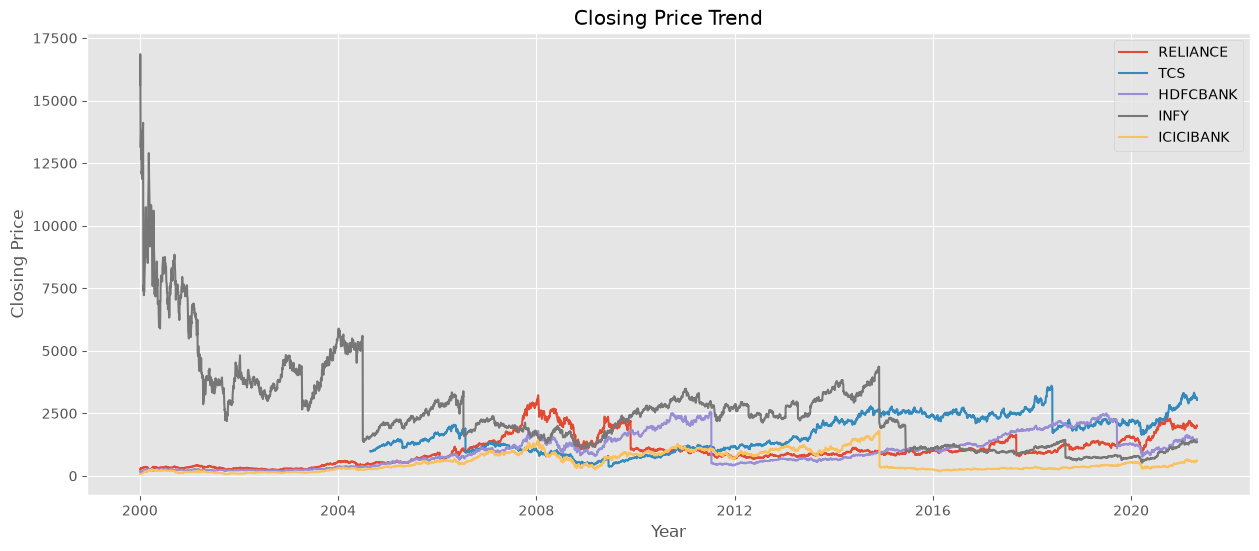

In [44]:
# Stock Performance Analysis

# Closing Price Trend of Selected Stocks

selected_stocks = [
    "RELIANCE",
    "TCS",
    "HDFCBANK",
    "INFY",
    "ICICIBANK"
]

plt.figure(figsize=(15,6))

for stock in selected_stocks:
    temp = stocks_df[stocks_df["Symbol"] == stock]

    plt.plot(
        temp["Date"],
        temp["Close"],
        label=stock
    )

plt.title("Closing Price Trend")
plt.xlabel("Year")
plt.ylabel("Closing Price")

plt.legend()

plt.show()

In [45]:
# Average Closing Price by Stock

avg_close = stocks_df.groupby("Symbol")["Close"].mean().sort_values(ascending=False)

avg_close.head()



Symbol
NESTLEIND     7512.039647
EICHERMOT     6751.063167
SHREECEM      6565.809539
MARUTI        2925.005094
BAJAJFINSV    2758.657451
Name: Close, dtype: float64

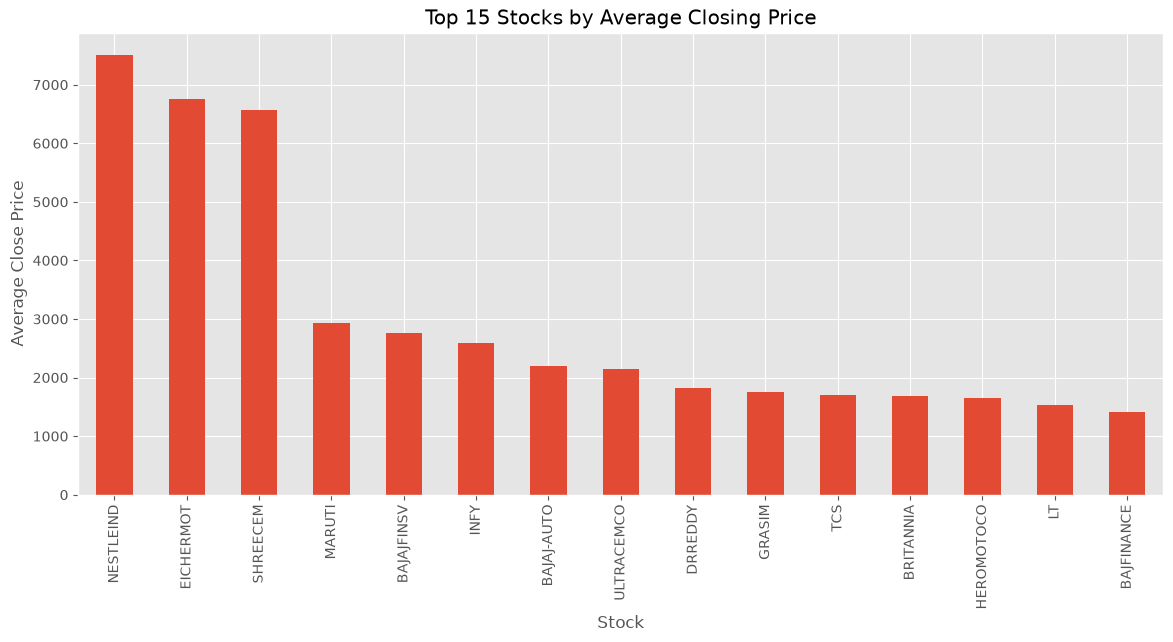

In [46]:
plt.figure(figsize=(14,6))

avg_close.head(15).plot(kind="bar")

plt.title("Top 15 Stocks by Average Closing Price")
plt.xlabel("Stock")
plt.ylabel("Average Close Price")

plt.show()

In [49]:
# Cumulative Return

# Cumulative Return=(∏(1+Daily Return))−1

cumulative_returns = (stocks_df.groupby("Symbol")["Daily Return"].apply(lambda x: (1 + x).cumprod() - 1)).sort_values(ascending=False)

cumulative_returns.head(10)

Symbol          
EICHERMOT  58566    671.711361
           58573    669.749232
           58569    667.615148
           58567    666.712385
           58568    664.273286
           58575    663.145343
           58574    662.335722
           58601    661.662231
           58602    658.844422
           58570    658.701126
Name: Daily Return, dtype: float64

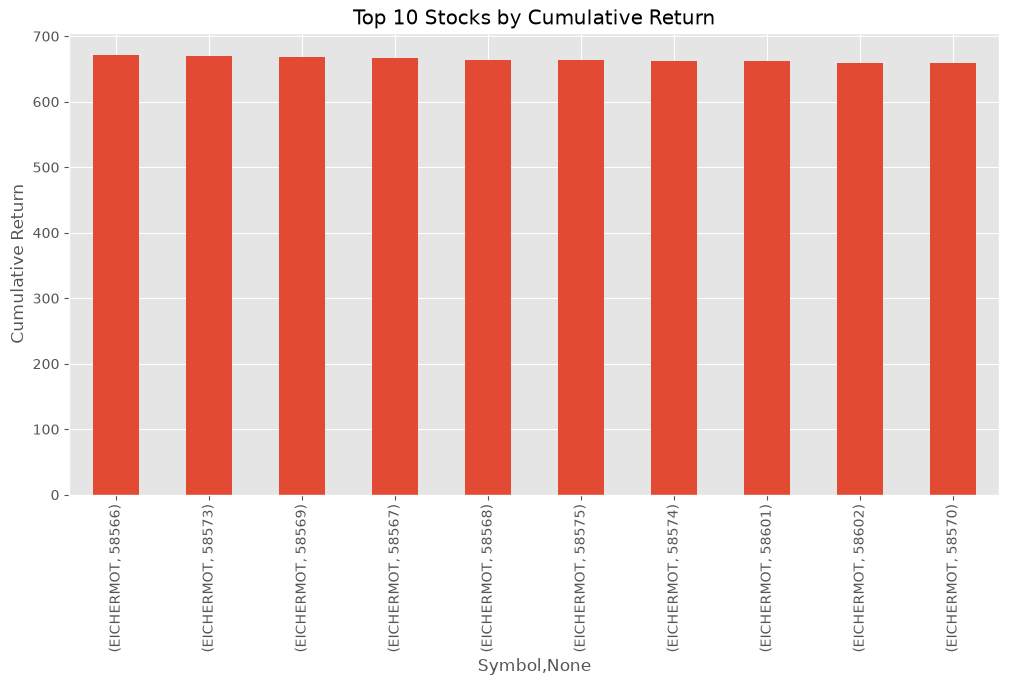

In [50]:
plt.figure(figsize=(12,6))

cumulative_returns.head(10).plot(kind="bar")

plt.title("Top 10 Stocks by Cumulative Return")
plt.ylabel("Cumulative Return")

plt.show()

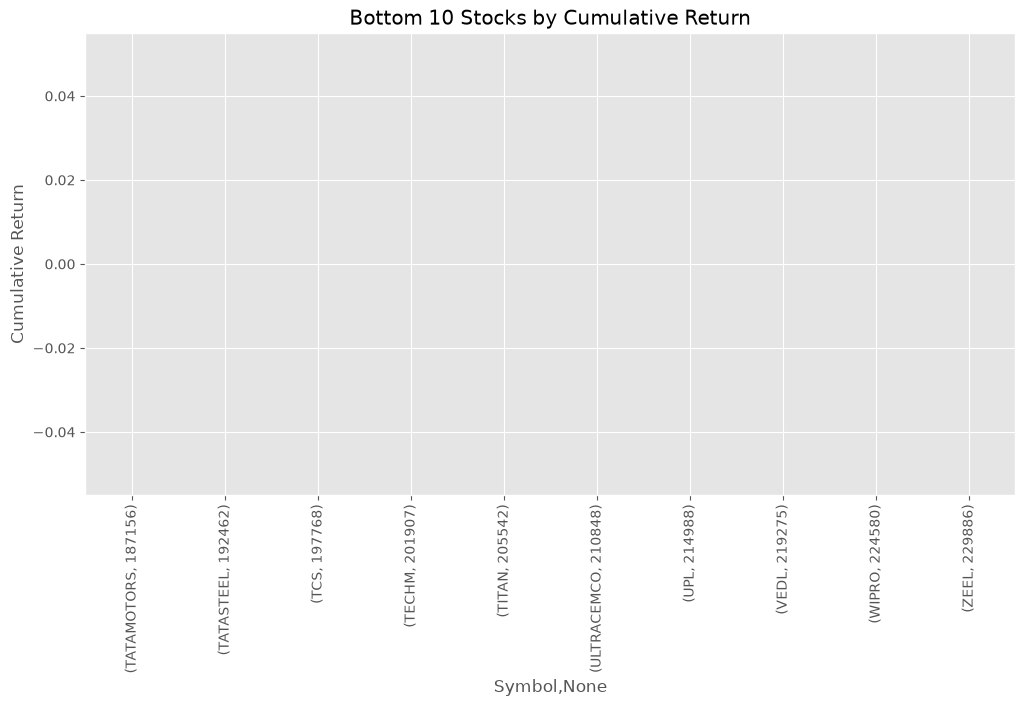

In [51]:
plt.figure(figsize=(12,6))

cumulative_returns.tail(10).plot(kind="bar")

plt.title("Bottom 10 Stocks by Cumulative Return")

plt.ylabel("Cumulative Return")

plt.show()

In [57]:
# Average Daily Return

avg_returns = (
    stocks_df.groupby("Symbol")["Daily Return"]
             .mean()
             .sort_values(ascending=False)
)

avg_returns.head()

Symbol
BAJFINANCE    0.001547
SHREECEM      0.001517
EICHERMOT     0.001377
BAJAJFINSV    0.001282
INDUSINDBK    0.001222
Name: Daily Return, dtype: float64

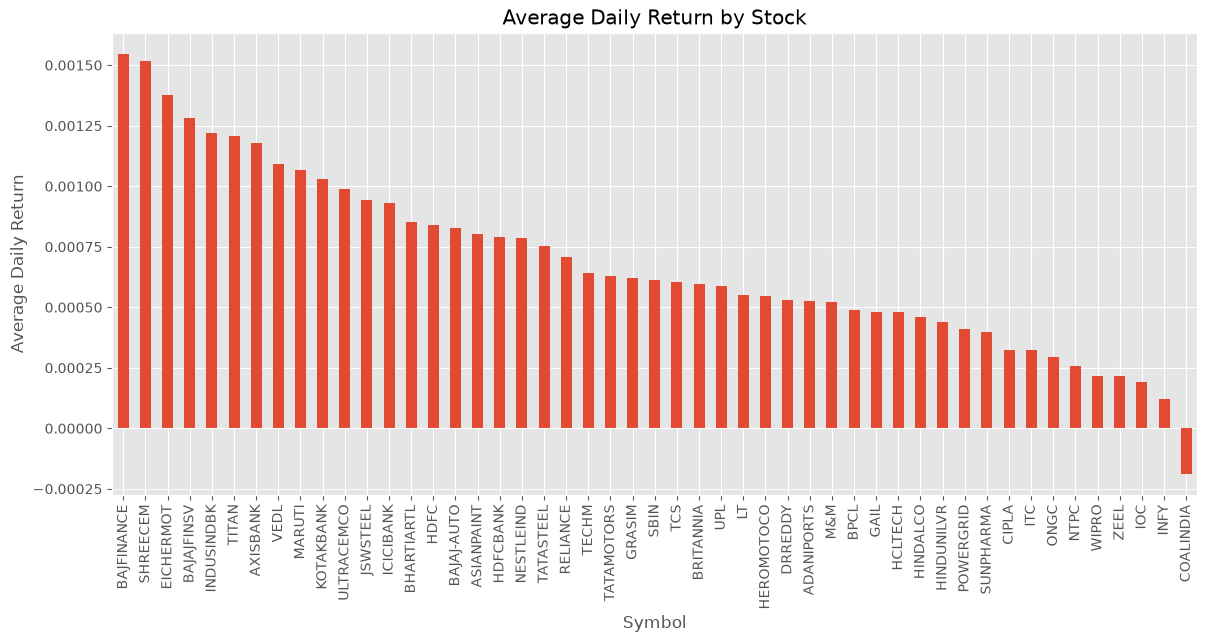

In [58]:
plt.figure(figsize=(14,6))

avg_returns.plot(kind="bar")

plt.title("Average Daily Return by Stock")

plt.ylabel("Average Daily Return")

plt.xticks(rotation=90)

plt.show()

In [62]:
# Monthly Returns

monthly_returns = (
    stocks_df.set_index("Date")
             .groupby("Symbol")["Close"]
             .resample("ME")
             .last()
             .pct_change()
             .reset_index()
)

monthly_returns.head()

,Symbol,Date,Close
0,ADANIPORTS,2007-11-30,NaN
1,ADANIPORTS,2007-12-31,0.376811
2,ADANIPORTS,2008-01-31,-0.339809
3,ADANIPORTS,2008-02-29,-0.121769
4,ADANIPORTS,2008-03-31,-0.213281


In [63]:
best_monthly = (
    monthly_returns.groupby("Symbol")["Close"]
                   .mean()
                   .sort_values(ascending=False)
)

best_monthly.head(10)

Symbol
WIPRO         0.057510
DRREDDY       0.046516
ITC           0.031024
HINDUNILVR    0.030892
SHREECEM      0.029808
INFY          0.029752
BAJFINANCE    0.029742
BAJAJFINSV    0.025481
EICHERMOT     0.024809
JSWSTEEL      0.024725
Name: Close, dtype: float64

In [64]:
# Best and Worst Single Trading Days

stocks_df.nlargest(
    10,
    "Daily Return"
)[["Date","Symbol","Daily Return"]]

,Date,Symbol,Daily Return
111608,2020-03-26,INDUSINDBK,0.446731
128699,2008-10-31,JSWSTEEL,0.337108
60243,2004-05-18,GAIL,0.320078
175995,2017-10-25,SBIN,0.276872
81461,2004-05-18,HDFCBANK,0.258174
207007,2005-10-31,TITAN,0.257244
202591,2009-06-09,TECHM,0.256120
216182,2008-10-31,UPL,0.256062
27379,2009-05-18,BHARTIARTL,0.254235
137994,2009-05-18,LT,0.245349


In [65]:
stocks_df.nsmallest(
    10,
    "Daily Return"
)[["Date","Symbol","Daily Return"]]

,Date,Symbol,Daily Return
221432,2008-08-08,VEDL,-0.946849
208408,2011-06-23,TITAN,-0.946674
123930,2005-09-21,ITC,-0.927342
130723,2017-01-04,JSWSTEEL,-0.900854
6714,2013-07-30,ASIANPAINT,-0.900209
59297,2020-08-24,EICHERMOT,-0.899714
24423,2016-09-08,BAJFINANCE,-0.897940
175270,2014-11-20,SBIN,-0.897921
92400,2005-08-30,HINDALCO,-0.897672
96409,2000-07-05,HINDUNILVR,-0.896562


# Risk Analysis

In [66]:
# Daily Volatility

volatility = (
    stocks_df.groupby("Symbol")["Daily Return"]
             .std()
             .sort_values(ascending=False)
)

volatility.head(10)

Symbol
VEDL          0.035807
ZEEL          0.033125
JSWSTEEL      0.032959
KOTAKBANK     0.032725
HCLTECH       0.032522
INDUSINDBK    0.031942
TITAN         0.031495
TATAMOTORS    0.030746
BAJFINANCE    0.030653
WIPRO         0.030610
Name: Daily Return, dtype: float64

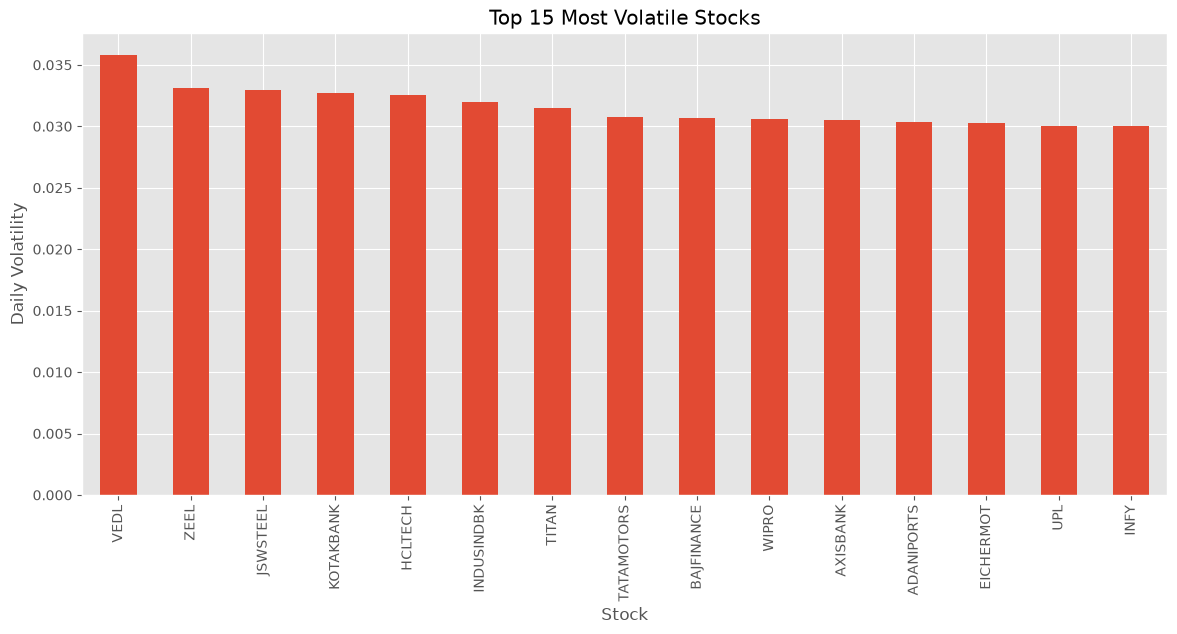

In [67]:
plt.figure(figsize=(14,6))

volatility.head(15).plot(kind="bar")

plt.title("Top 15 Most Volatile Stocks")
plt.xlabel("Stock")
plt.ylabel("Daily Volatility")

plt.show()

In [68]:
# Annualized Volatility

annual_volatility = volatility * np.sqrt(252)

annual_volatility.sort_values(
    ascending=False
).head(10)

Symbol
VEDL          0.568411
ZEEL          0.525844
JSWSTEEL      0.523214
KOTAKBANK     0.519487
HCLTECH       0.516271
INDUSINDBK    0.507056
TITAN         0.499968
TATAMOTORS    0.488073
BAJFINANCE    0.486609
WIPRO         0.485925
Name: Daily Return, dtype: float64

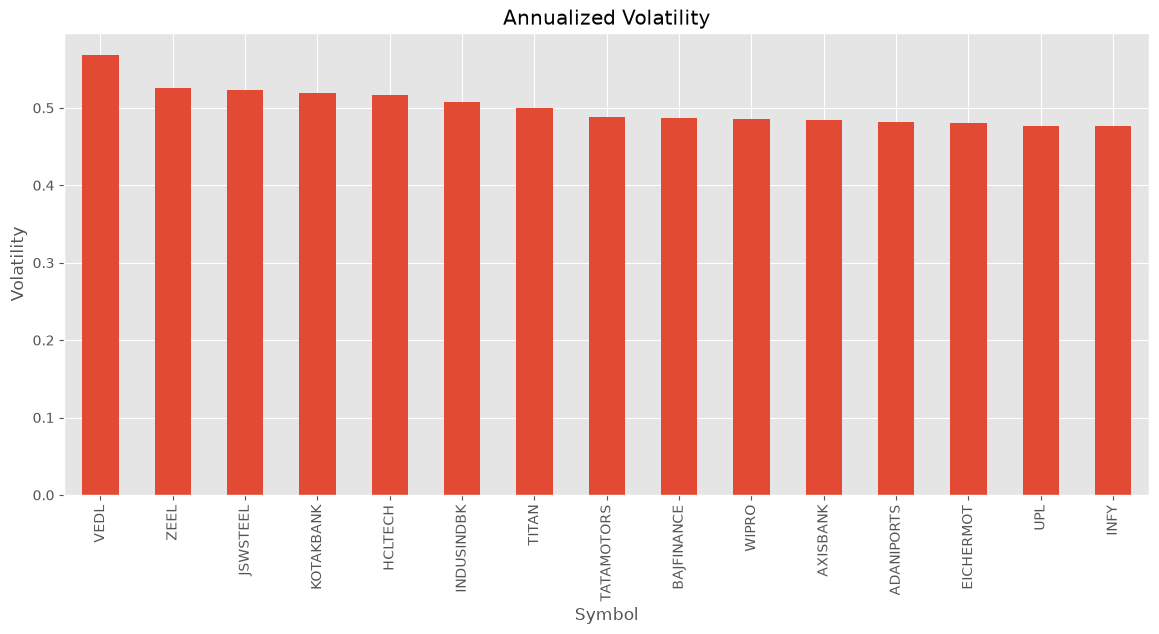

In [69]:
plt.figure(figsize=(14,6))

annual_volatility.head(15).plot(kind="bar")

plt.title("Annualized Volatility")
plt.ylabel("Volatility")

plt.show()

In [70]:
# Rolling Volatility

reliance = stocks_df[
    stocks_df["Symbol"]=="RELIANCE"
].copy()

reliance["Rolling Volatility"] = (
    reliance["Daily Return"]
    .rolling(30)
    .std()
)

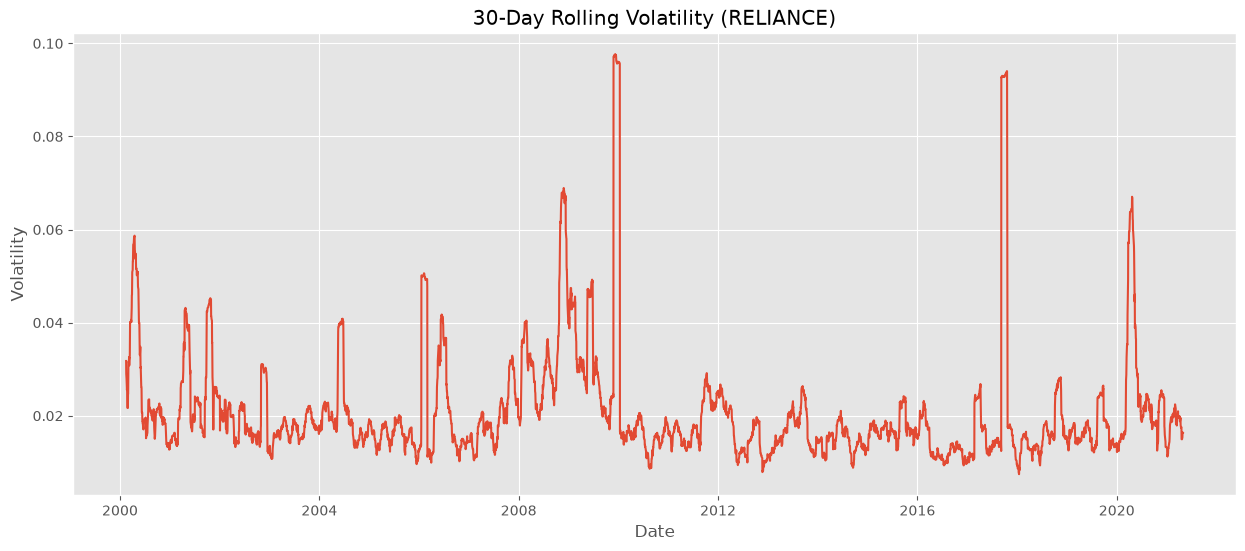

In [71]:
plt.figure(figsize=(15,6))

plt.plot(
    reliance["Date"],
    reliance["Rolling Volatility"]
)

plt.title("30-Day Rolling Volatility (RELIANCE)")

plt.xlabel("Date")

plt.ylabel("Volatility")

plt.show()

In [72]:
# Maximum Drawdown

def max_drawdown(close_prices):
    cumulative_max = close_prices.cummax()

    drawdown = (
        close_prices - cumulative_max
    ) / cumulative_max

    return drawdown.min()

In [73]:
drawdowns = (
    stocks_df.groupby("Symbol")["Close"]
             .apply(max_drawdown)
             .sort_values()
)

drawdowns.head(10)

Symbol
VEDL         -0.985832
WIPRO        -0.983066
HINDALCO     -0.974603
INFY         -0.968768
HCLTECH      -0.968182
TITAN        -0.966869
HINDUNILVR   -0.966208
ZEEL         -0.959590
ONGC         -0.959574
SBIN         -0.956776
Name: Close, dtype: float64

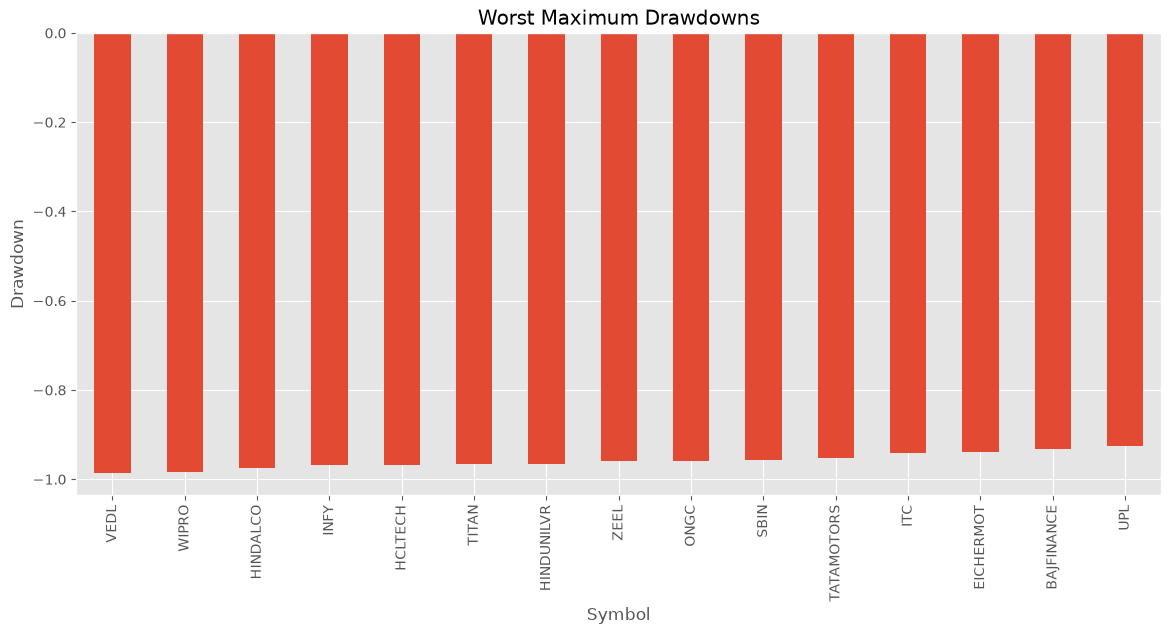

In [74]:
plt.figure(figsize=(14,6))

drawdowns.head(15).plot(kind="bar")

plt.title("Worst Maximum Drawdowns")

plt.ylabel("Drawdown")

plt.show()

In [75]:
# Risk Ranking

risk_summary = pd.DataFrame({
    "Average Return": stocks_df.groupby("Symbol")["Daily Return"].mean(),
    "Volatility": stocks_df.groupby("Symbol")["Daily Return"].std(),
    "Annual Volatility": annual_volatility,
    "Maximum Drawdown": drawdowns
})

risk_summary

,Average Return,Volatility,Annual Volatility,Maximum Drawdown
Symbol,,,,
ADANIPORTS,0.000526,0.030370,0.482108,-0.917396
ASIANPAINT,0.000804,0.022355,0.354875,-0.924805
AXISBANK,0.001178,0.030541,0.484830,-0.850174
BAJAJ-AUTO,0.000827,0.021345,0.338834,-0.599151
BAJAJFINSV,0.001282,0.025257,0.400940,-0.867894
BAJFINANCE,0.001547,0.030653,0.486609,-0.932820
BHARTIARTL,0.000850,0.025191,0.399899,-0.784747
BPCL,0.000488,0.029491,0.468156,-0.773052
BRITANNIA,0.000598,0.021146,0.335686,-0.853630


In [76]:
risk_summary.sort_values(
    "Volatility",
    ascending=False
).head(10)

,Average Return,Volatility,Annual Volatility,Maximum Drawdown
Symbol,,,,
VEDL,0.001091,0.035807,0.568411,-0.985832
ZEEL,0.000216,0.033125,0.525844,-0.959590
JSWSTEEL,0.000943,0.032959,0.523214,-0.924458
KOTAKBANK,0.001030,0.032725,0.519487,-0.889451
HCLTECH,0.000481,0.032522,0.516271,-0.968182
INDUSINDBK,0.001222,0.031942,0.507056,-0.851066
TITAN,0.001206,0.031495,0.499968,-0.966869
TATAMOTORS,0.000627,0.030746,0.488073,-0.952166
BAJFINANCE,0.001547,0.030653,0.486609,-0.932820


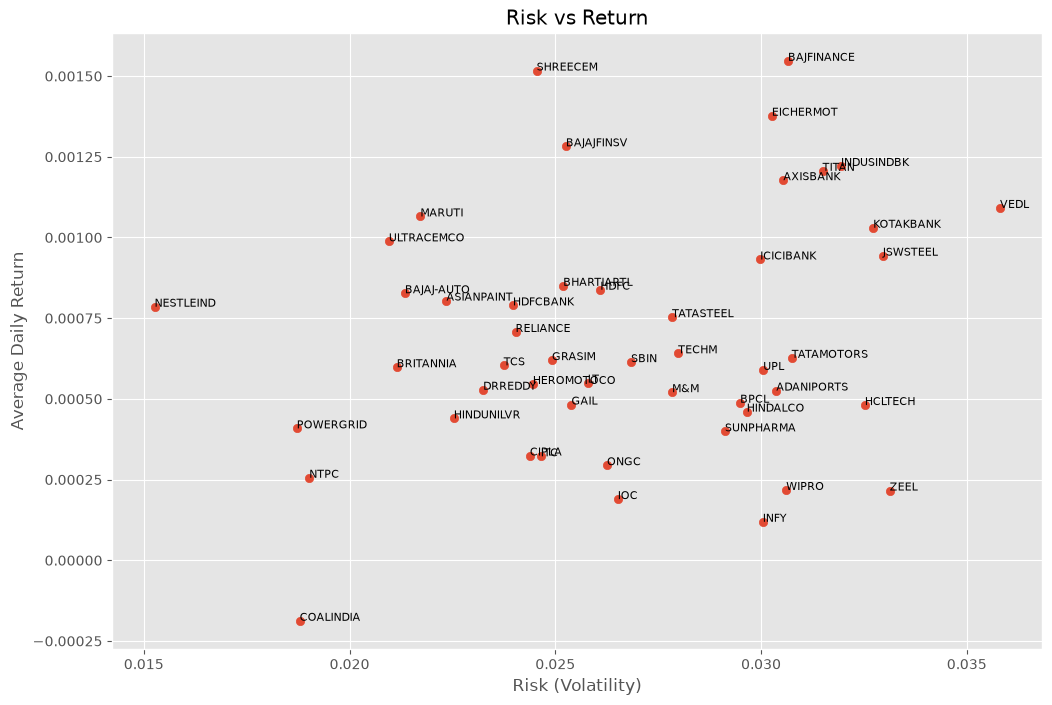

In [77]:
# Risk vs Return Scatter Plot

plt.figure(figsize=(12,8))

plt.scatter(
    risk_summary["Volatility"],
    risk_summary["Average Return"]
)

for stock in risk_summary.index:
    plt.text(
        risk_summary.loc[stock, "Volatility"],
        risk_summary.loc[stock, "Average Return"],
        stock,
        fontsize=8
    )

plt.xlabel("Risk (Volatility)")
plt.ylabel("Average Daily Return")

plt.title("Risk vs Return")

plt.show()

In [78]:
# Sharpe Ratio (Without Risk-Free Rate)

risk_summary["Sharpe Ratio"] = (
    risk_summary["Average Return"] /
    risk_summary["Volatility"]
)

In [79]:
risk_summary.sort_values(
    "Sharpe Ratio",
    ascending=False
).head(10)

,Average Return,Volatility,Annual Volatility,Maximum Drawdown,Sharpe Ratio
Symbol,,,,,
SHREECEM,0.001517,0.024547,0.389665,-0.799734,0.061803
NESTLEIND,0.000785,0.015261,0.242261,-0.324011,0.051471
BAJAJFINSV,0.001282,0.025257,0.400940,-0.867894,0.050772
BAJFINANCE,0.001547,0.030653,0.486609,-0.932820,0.050475
MARUTI,0.001065,0.021721,0.344806,-0.613397,0.049041
ULTRACEMCO,0.000988,0.020955,0.332647,-0.777797,0.047145
EICHERMOT,0.001377,0.030262,0.480399,-0.938237,0.045507
BAJAJ-AUTO,0.000827,0.021345,0.338834,-0.599151,0.038753
AXISBANK,0.001178,0.030541,0.484830,-0.850174,0.038554


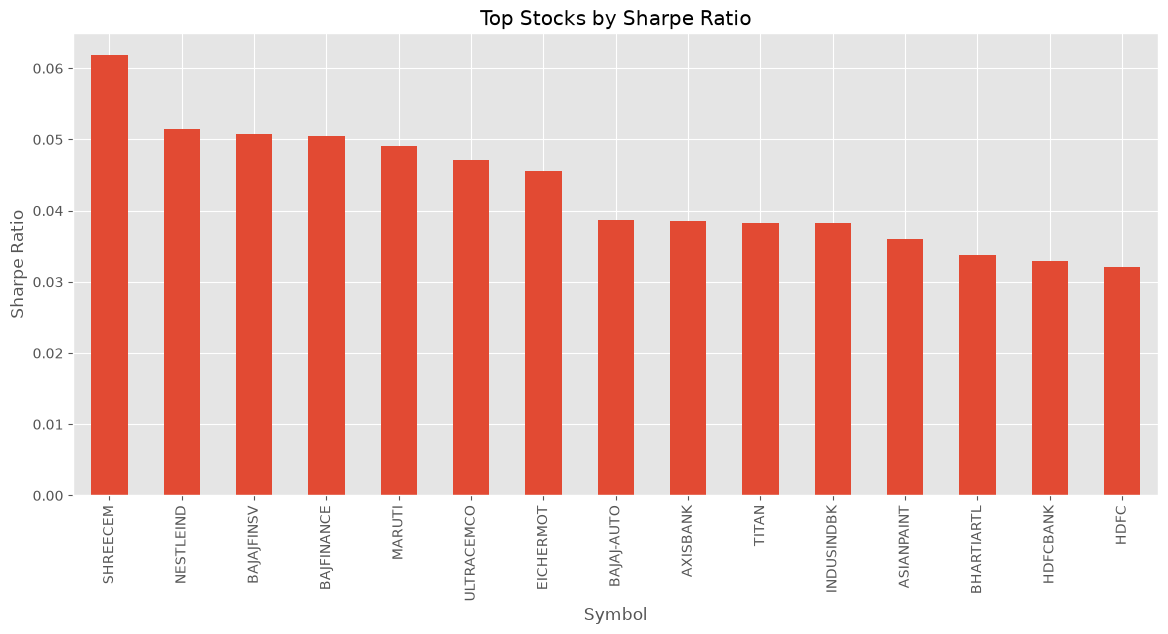

In [80]:
plt.figure(figsize=(14,6))

risk_summary.sort_values(
    "Sharpe Ratio",
    ascending=False
).head(15)["Sharpe Ratio"].plot(kind="bar")

plt.title("Top Stocks by Sharpe Ratio")

plt.ylabel("Sharpe Ratio")

plt.show()

# Sector Analysis

In [81]:
# Number of Companies per Industry

industry_counts = (
    stocks_df[["Symbol", "Industry"]]
    .drop_duplicates()
    .groupby("Industry")
    .size()
    .sort_values(ascending=False)
)

industry_counts

Industry
FINANCIAL SERVICES          9
ENERGY                      7
AUTOMOBILE                  6
CONSUMER GOODS              6
IT                          5
METALS                      5
CEMENT & CEMENT PRODUCTS    3
PHARMA                      3
CONSTRUCTION                1
MEDIA & ENTERTAINMENT       1
FERTILISERS & PESTICIDES    1
SERVICES                    1
TELECOM                     1
dtype: int64

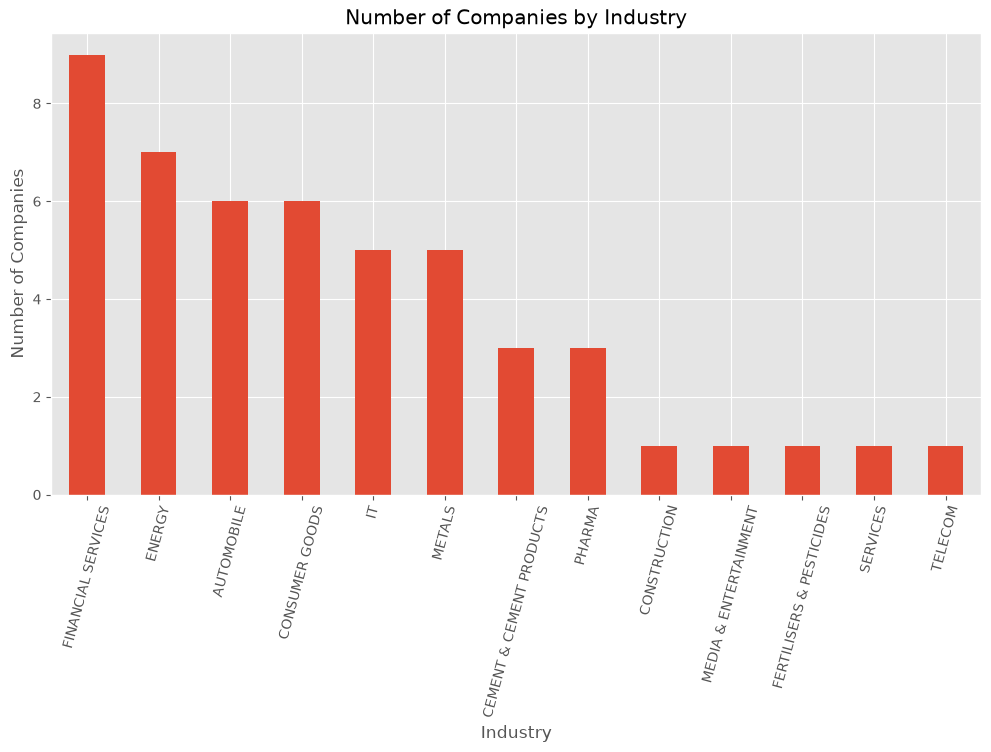

In [82]:
plt.figure(figsize=(12,6))

industry_counts.plot(kind="bar")

plt.title("Number of Companies by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Companies")

plt.xticks(rotation=75)

plt.show()

In [83]:
# Industry-wise Average Daily Return
industry_returns = (
    stocks_df.groupby("Industry")["Daily Return"]
             .mean()
             .sort_values(ascending=False)
)

industry_returns

Industry
CEMENT & CEMENT PRODUCTS    0.001035
FINANCIAL SERVICES          0.001035
TELECOM                     0.000850
AUTOMOBILE                  0.000820
METALS                      0.000689
CONSUMER GOODS              0.000685
FERTILISERS & PESTICIDES    0.000590
CONSTRUCTION                0.000550
SERVICES                    0.000526
PHARMA                      0.000417
ENERGY                      0.000408
IT                          0.000387
MEDIA & ENTERTAINMENT       0.000216
Name: Daily Return, dtype: float64

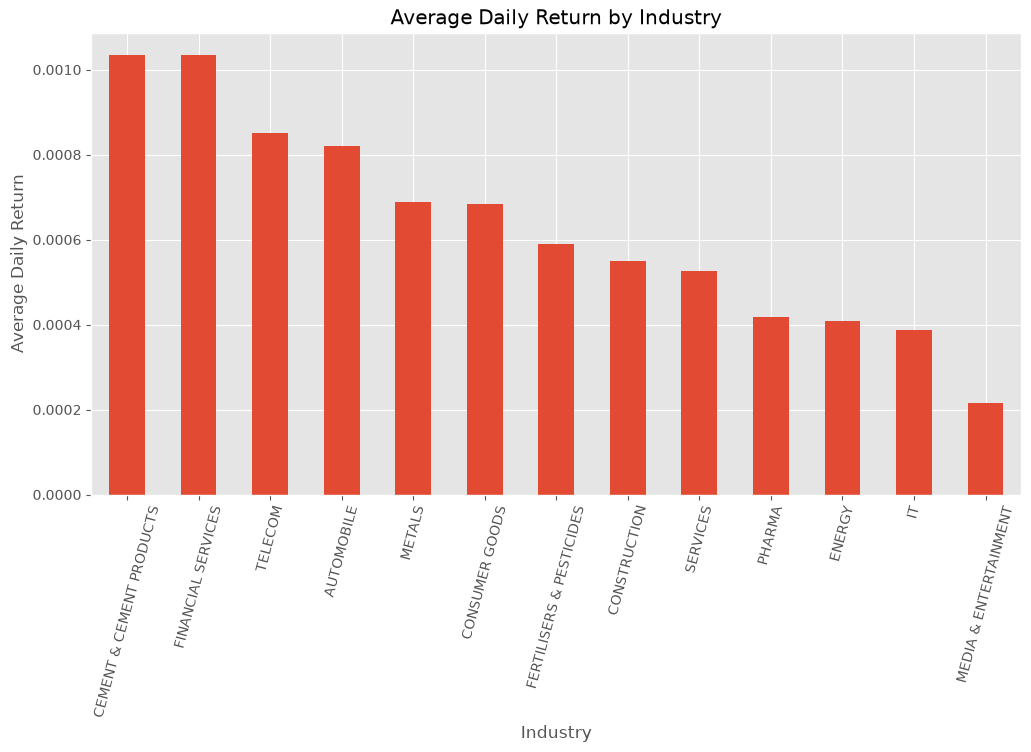

In [84]:
plt.figure(figsize=(12,6))

industry_returns.plot(kind="bar")

plt.title("Average Daily Return by Industry")
plt.ylabel("Average Daily Return")

plt.xticks(rotation=75)

plt.show()

In [85]:
#Industry-wise Volatility

industry_volatility = (
    stocks_df.groupby("Industry")["Daily Return"]
             .std()
             .sort_values(ascending=False)
)

industry_volatility

Industry
MEDIA & ENTERTAINMENT       0.033125
METALS                      0.030424
SERVICES                    0.030370
FERTILISERS & PESTICIDES    0.030052
IT                          0.029451
FINANCIAL SERVICES          0.028920
AUTOMOBILE                  0.026789
CONSTRUCTION                0.025787
PHARMA                      0.025709
TELECOM                     0.025191
ENERGY                      0.024941
CONSUMER GOODS              0.023972
CEMENT & CEMENT PRODUCTS    0.023717
Name: Daily Return, dtype: float64

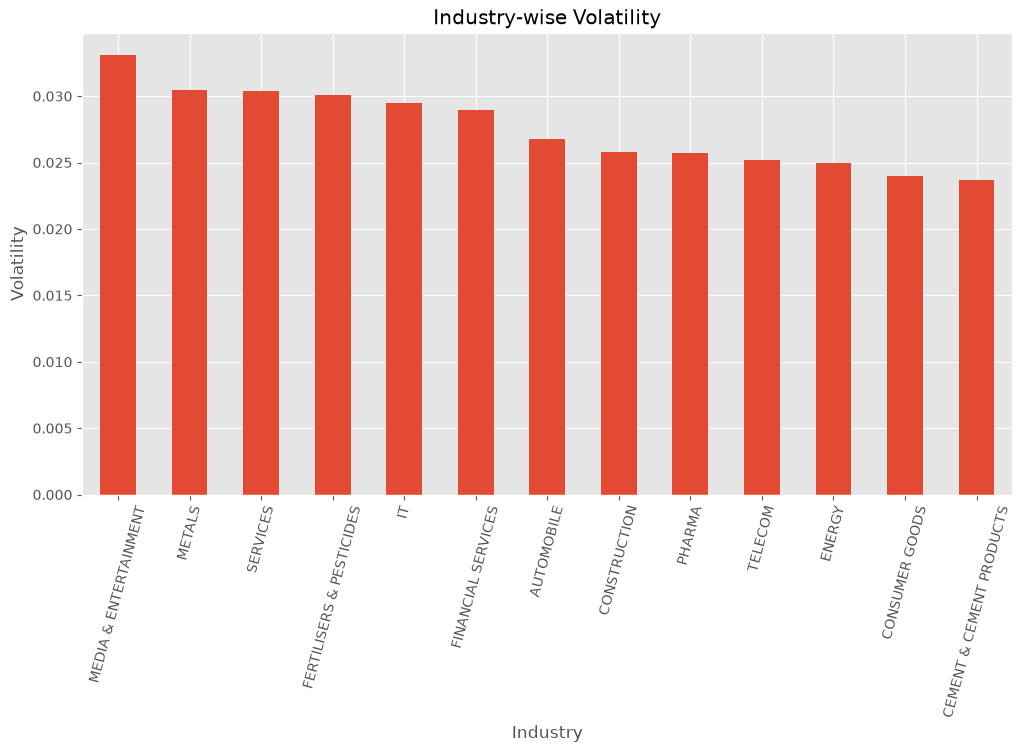

In [86]:
plt.figure(figsize=(12,6))

industry_volatility.plot(kind="bar")

plt.title("Industry-wise Volatility")
plt.ylabel("Volatility")

plt.xticks(rotation=75)

plt.show()

In [87]:
# Industry Risk vs Return

industry_summary = pd.DataFrame({
    "Average Return": industry_returns,
    "Volatility": industry_volatility
})

industry_summary

,Average Return,Volatility
Industry,,
AUTOMOBILE,0.000820,0.026789
CEMENT & CEMENT PRODUCTS,0.001035,0.023717
CONSTRUCTION,0.000550,0.025787
CONSUMER GOODS,0.000685,0.023972
ENERGY,0.000408,0.024941
FERTILISERS & PESTICIDES,0.000590,0.030052
FINANCIAL SERVICES,0.001035,0.028920
IT,0.000387,0.029451
MEDIA & ENTERTAINMENT,0.000216,0.033125


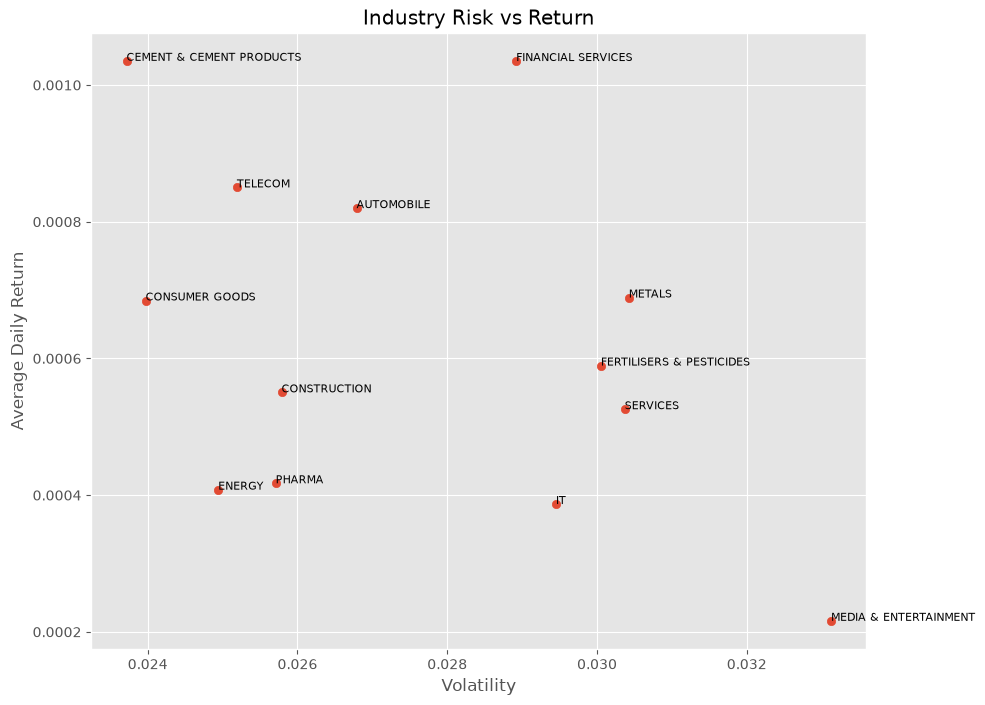

In [88]:
plt.figure(figsize=(10,8))

plt.scatter(
    industry_summary["Volatility"],
    industry_summary["Average Return"]
)

for industry in industry_summary.index:
    plt.text(
        industry_summary.loc[industry, "Volatility"],
        industry_summary.loc[industry, "Average Return"],
        industry,
        fontsize=8
    )

plt.xlabel("Volatility")
plt.ylabel("Average Daily Return")

plt.title("Industry Risk vs Return")

plt.show()

In [89]:
# Industry-wise Sharpe Ratio

industry_summary["Sharpe Ratio"] = (
    industry_summary["Average Return"] /
    industry_summary["Volatility"]
)

industry_summary.sort_values(
    "Sharpe Ratio",
    ascending=False
)

,Average Return,Volatility,Sharpe Ratio
Industry,,,
CEMENT & CEMENT PRODUCTS,0.001035,0.023717,0.043657
FINANCIAL SERVICES,0.001035,0.028920,0.035792
TELECOM,0.000850,0.025191,0.033750
AUTOMOBILE,0.000820,0.026789,0.030606
CONSUMER GOODS,0.000685,0.023972,0.028564
METALS,0.000689,0.030424,0.022650
CONSTRUCTION,0.000550,0.025787,0.021340
FERTILISERS & PESTICIDES,0.000590,0.030052,0.019619
SERVICES,0.000526,0.030370,0.017309


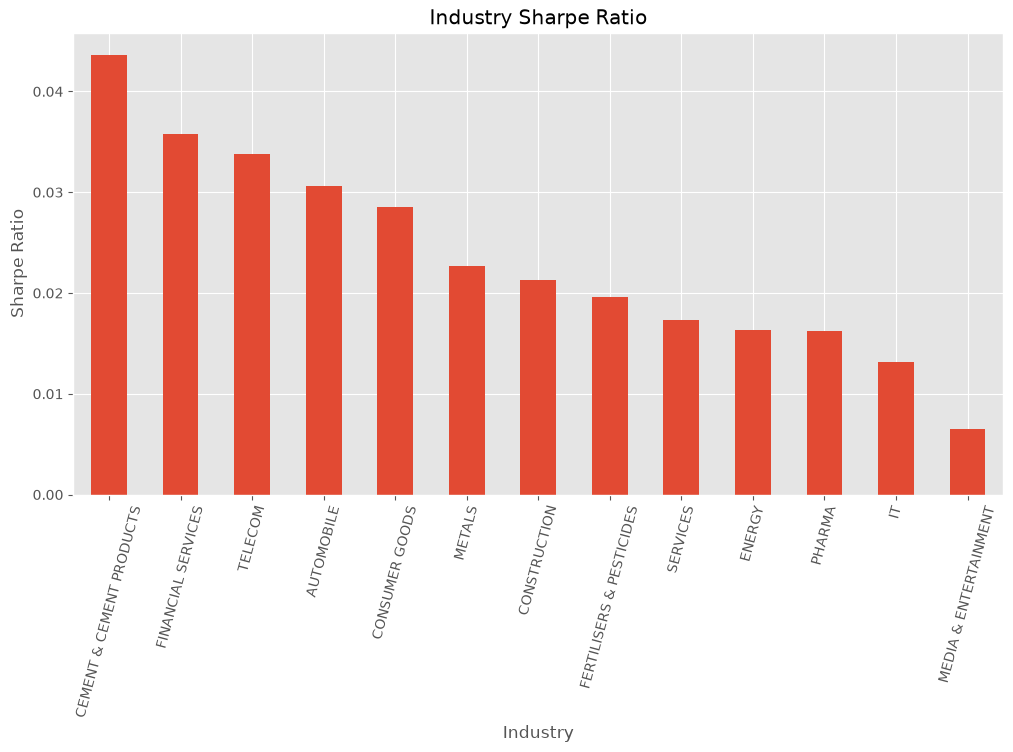

In [90]:
plt.figure(figsize=(12,6))

industry_summary.sort_values(
    "Sharpe Ratio",
    ascending=False
)["Sharpe Ratio"].plot(kind="bar")

plt.title("Industry Sharpe Ratio")
plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=75)

plt.show()

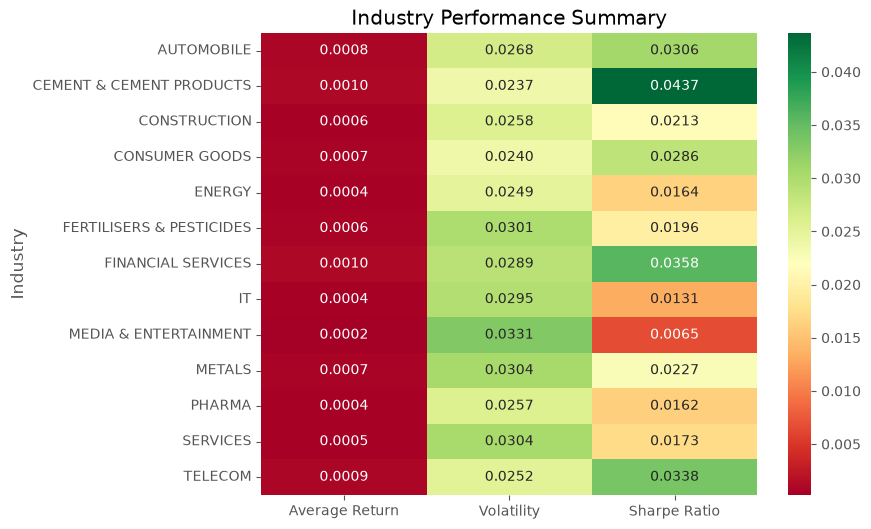

In [91]:
# Industry Performance Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    industry_summary,
    annot=True,
    cmap="RdYlGn",
    fmt=".4f"
)

plt.title("Industry Performance Summary")

plt.show()

# Correlation Analysis

In [92]:
# Create Returns Matrix

returns_matrix = stocks_df.pivot_table(
    index="Date",
    columns="Symbol",
    values="Daily Return"
)

returns_matrix.head()

Symbol,ADANIPORTS,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJAJFINSV,BAJFINANCE,BHARTIARTL,BPCL,BRITANNIA,CIPLA,...,TATAMOTORS,TATASTEEL,TCS,TECHM,TITAN,ULTRACEMCO,UPL,VEDL,WIPRO,ZEEL
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-04,NaN,0.010219,0.005618,NaN,NaN,-0.052217,NaN,-0.072010,-0.003105,0.005421,...,-0.039446,-0.010823,NaN,NaN,-0.053308,NaN,NaN,-0.014181,0.080005,0.068393
2000-01-05,NaN,-0.006614,-0.020484,NaN,NaN,-0.072765,NaN,-0.028475,-0.025512,-0.020611,...,0.024256,0.038130,NaN,NaN,-0.061058,NaN,NaN,-0.006103,0.016298,-0.066712
2000-01-06,NaN,-0.014360,-0.013308,NaN,NaN,0.014574,NaN,0.056536,0.068475,-0.055190,...,0.041501,0.074737,NaN,NaN,0.080202,NaN,NaN,0.046491,-0.019347,-0.051931
2000-01-07,NaN,0.021722,-0.044316,NaN,NaN,-0.051934,NaN,-0.001183,0.079997,-0.079876,...,0.080144,0.021991,NaN,NaN,-0.021070,NaN,NaN,-0.023470,-0.079990,-0.079968
2000-01-10,NaN,0.075966,0.008065,NaN,NaN,0.000000,NaN,0.013426,0.075074,-0.033385,...,0.078991,0.059901,NaN,NaN,-0.009908,NaN,NaN,0.021459,0.001353,-0.058027


In [93]:
# Correlation Matrix

correlation_matrix = returns_matrix.corr()

correlation_matrix.head()

Symbol,ADANIPORTS,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJAJFINSV,BAJFINANCE,BHARTIARTL,BPCL,BRITANNIA,CIPLA,...,TATAMOTORS,TATASTEEL,TCS,TECHM,TITAN,ULTRACEMCO,UPL,VEDL,WIPRO,ZEEL
Symbol,,,,,,,,,,,,,,,,,,,,,
ADANIPORTS,1.000000,0.178910,0.319211,0.227316,0.248051,0.215115,0.202000,0.196708,0.133936,0.216376,...,0.261175,0.350038,0.151581,0.228492,0.194798,0.311123,0.260183,0.273013,0.168403,0.231443
ASIANPAINT,0.178910,1.000000,0.157451,0.218185,0.185120,0.144589,0.141932,0.150997,0.148968,0.090270,...,0.167034,0.200582,0.094135,0.124310,0.145127,0.224976,0.148443,0.134263,0.101458,0.122421
AXISBANK,0.319211,0.157451,1.000000,0.309746,0.310126,0.273914,0.263914,0.226701,0.130503,0.178520,...,0.337982,0.386283,0.200098,0.260026,0.287367,0.344146,0.288769,0.268927,0.230540,0.259902
BAJAJ-AUTO,0.227316,0.218185,0.309746,1.000000,0.266579,0.226711,0.232705,0.193248,0.368945,0.202791,...,0.287034,0.317570,0.187755,0.181102,0.223947,0.314067,0.252274,0.233407,0.190239,0.231238
BAJAJFINSV,0.248051,0.185120,0.310126,0.266579,1.000000,0.380370,0.182361,0.205708,0.150533,0.178484,...,0.264348,0.342918,0.131773,0.210991,0.203788,0.306330,0.272197,0.248953,0.159480,0.234850


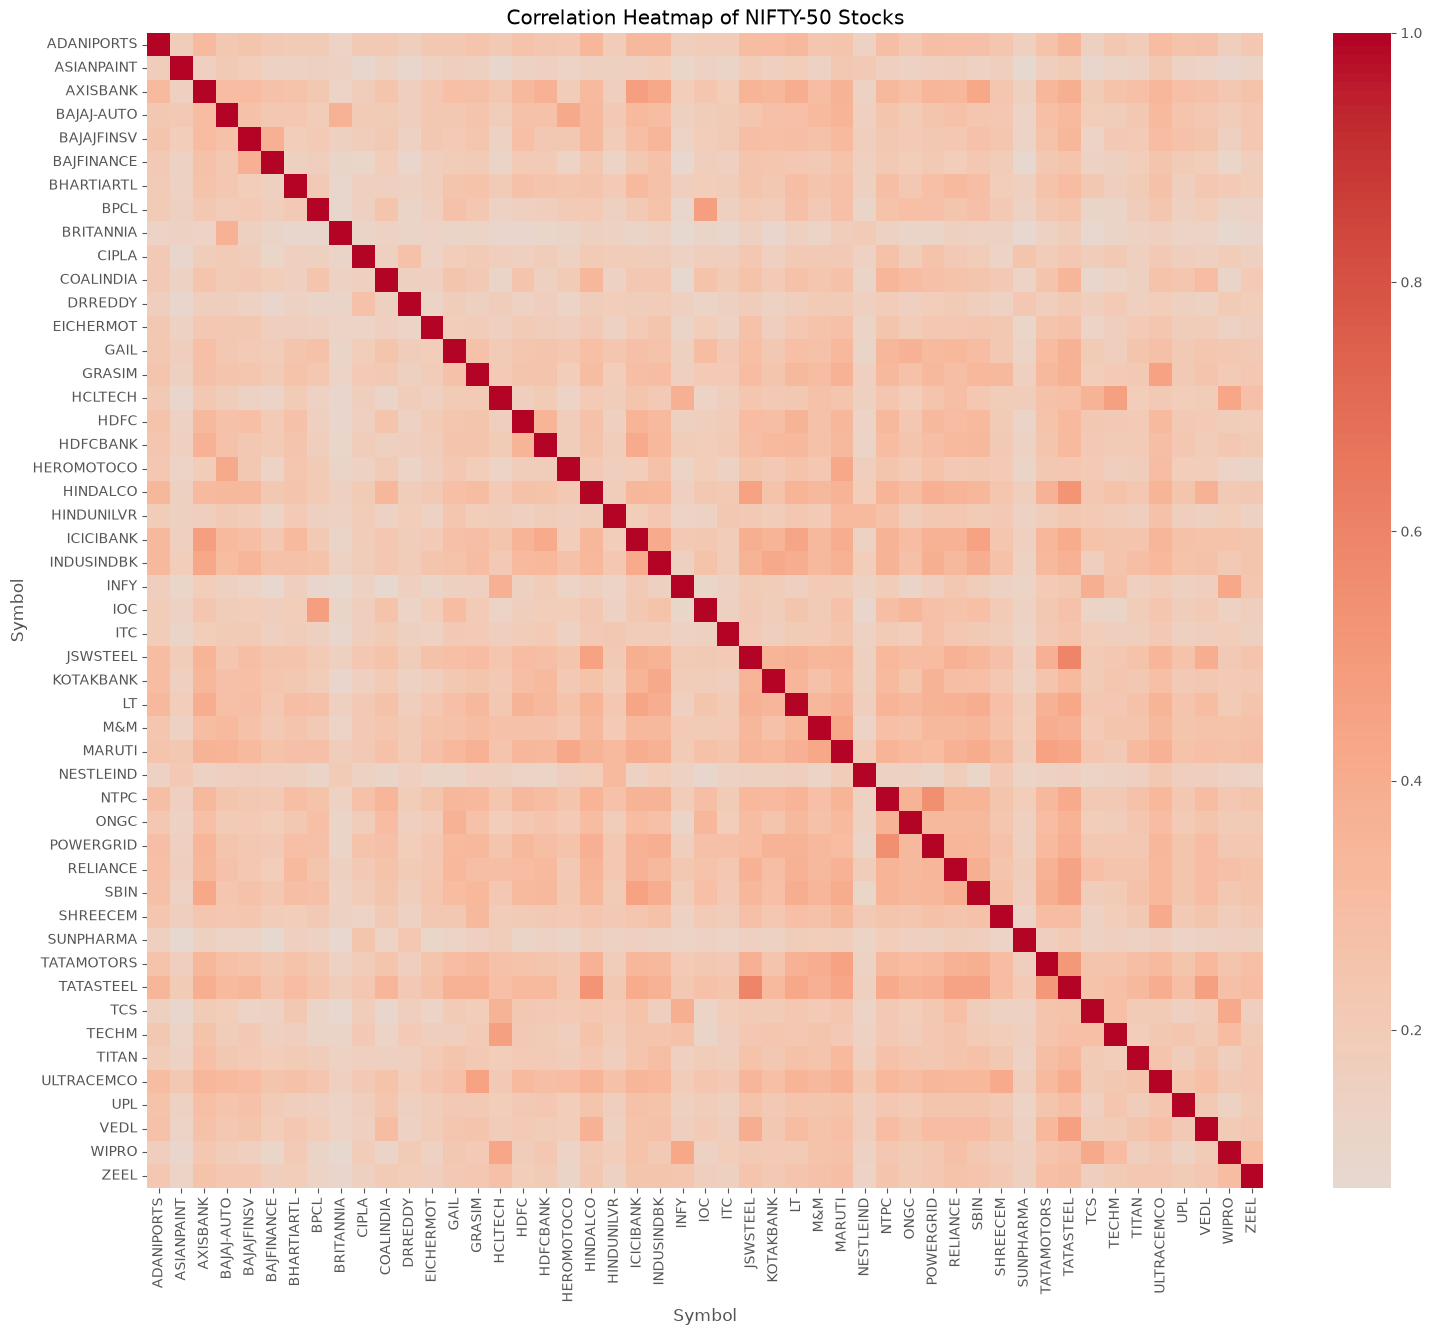

In [94]:
# Correlation Heatmap

plt.figure(figsize=(18,15))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of NIFTY-50 Stocks")

plt.show()

In [97]:
# Most Positively Correlated Stock Pairs

# Remove axis names
correlation_matrix.index.name = None
correlation_matrix.columns.name = None

corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index(name="Correlation")
)

corr_pairs.columns = [
    "Stock 1",
    "Stock 2",
    "Correlation"
]

corr_pairs.sort_values(
    "Correlation",
    ascending=False
).head(10)

,Stock 1,Stock 2,Correlation
1314,JSWSTEEL,TATASTEEL,0.598359
1602,NTPC,POWERGRID,0.550588
971,HINDALCO,TATASTEEL,0.523385
1951,TATAMOTORS,TATASTEEL,0.500627
367,BPCL,IOC,0.472257
119,AXISBANK,ICICIBANK,0.469427
2006,TATASTEEL,VEDL,0.465057
777,HCLTECH,TECHM,0.464330
730,GRASIM,ULTRACEMCO,0.459941
1065,ICICIBANK,SBIN,0.458711


In [98]:
# Least Correlated Stock Pairs

corr_pairs.sort_values(
    "Correlation"
).head(10)

,Stock 1,Stock 2,Correlation
283,BAJFINANCE,SUNPHARMA,0.073347
87,ASIANPAINT,SUNPHARMA,0.075364
513,COALINDIA,INFY,0.076268
415,BRITANNIA,INFY,0.079283
439,BRITANNIA,WIPRO,0.080017
430,BRITANNIA,SUNPHARMA,0.083282
433,BRITANNIA,TCS,0.086738
268,BAJFINANCE,INFY,0.087534
417,BRITANNIA,ITC,0.087920
1207,IOC,NESTLEIND,0.089750


In [99]:
# Average Correlation of Each Stock

average_corr = correlation_matrix.mean().sort_values()

average_corr.head()

BRITANNIA     0.149450
SUNPHARMA     0.167286
ASIANPAINT    0.168328
NESTLEIND     0.172232
DRREDDY       0.184095
dtype: float64

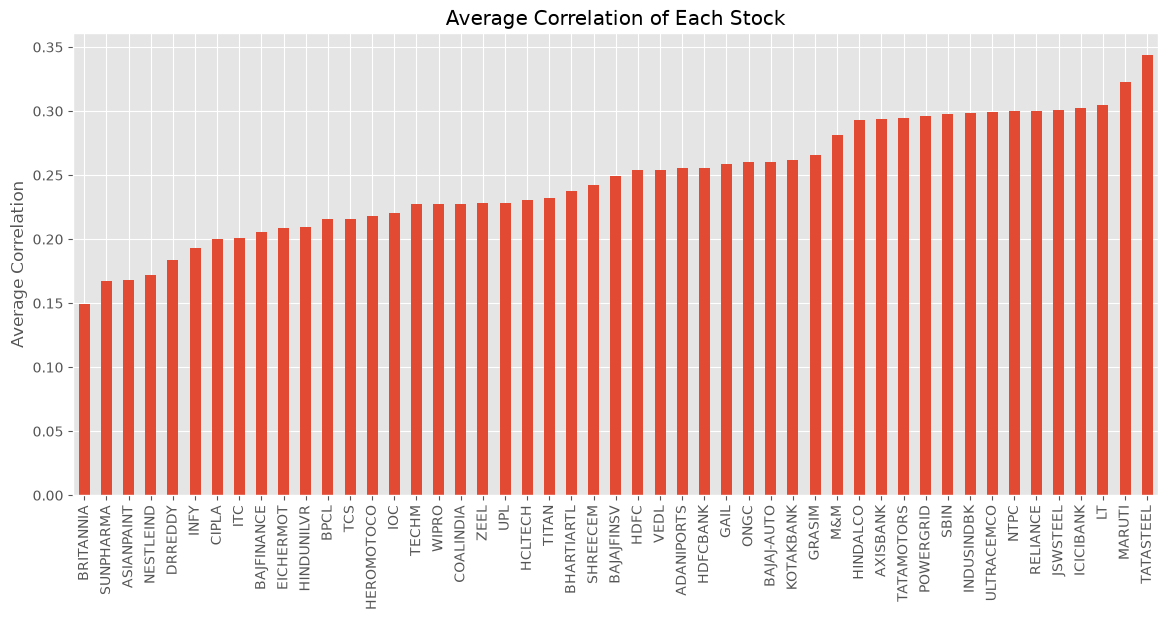

In [100]:
plt.figure(figsize=(14,6))

average_corr.plot(kind="bar")

plt.title("Average Correlation of Each Stock")
plt.ylabel("Average Correlation")

plt.xticks(rotation=90)

plt.show()

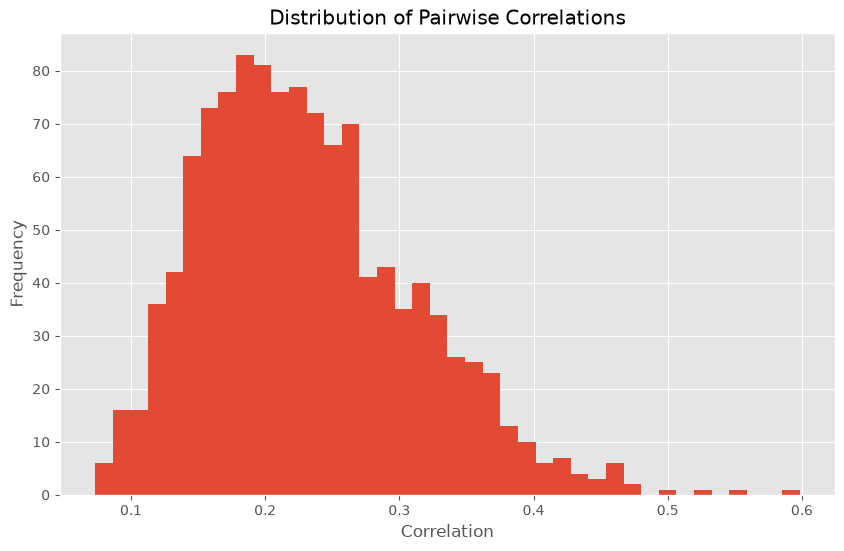

In [101]:
# Correlation Distribution

plt.figure(figsize=(10,6))

plt.hist(
    corr_pairs["Correlation"],
    bins=40
)

plt.title("Distribution of Pairwise Correlations")
plt.xlabel("Correlation")
plt.ylabel("Frequency")

plt.show()

In [102]:
# High Correlation Table

high_corr = corr_pairs[
    corr_pairs["Correlation"] > 0.80
]

high_corr.sort_values(
    "Correlation",
    ascending=False
)

,Stock 1,Stock 2,Correlation


# End-of-EDA Summary

In [103]:
eda_summary = pd.DataFrame({
    "Average Return": stocks_df.groupby("Symbol")["Daily Return"].mean(),
    "Volatility": stocks_df.groupby("Symbol")["Daily Return"].std(),
    "Annual Volatility": annual_volatility,
    "Maximum Drawdown": drawdowns,
    "Sharpe Ratio": risk_summary["Sharpe Ratio"],
    "Average Correlation": average_corr
})

eda_summary.sort_values(
    "Sharpe Ratio",
    ascending=False
).head(10)

,Average Return,Volatility,Annual Volatility,Maximum Drawdown,Sharpe Ratio,Average Correlation
SHREECEM,0.001517,0.024547,0.389665,-0.799734,0.061803,0.242114
NESTLEIND,0.000785,0.015261,0.242261,-0.324011,0.051471,0.172232
BAJAJFINSV,0.001282,0.025257,0.400940,-0.867894,0.050772,0.249614
BAJFINANCE,0.001547,0.030653,0.486609,-0.932820,0.050475,0.205895
MARUTI,0.001065,0.021721,0.344806,-0.613397,0.049041,0.322424
ULTRACEMCO,0.000988,0.020955,0.332647,-0.777797,0.047145,0.299103
EICHERMOT,0.001377,0.030262,0.480399,-0.938237,0.045507,0.208322
BAJAJ-AUTO,0.000827,0.021345,0.338834,-0.599151,0.038753,0.260597
AXISBANK,0.001178,0.030541,0.484830,-0.850174,0.038554,0.293749
TITAN,0.001206,0.031495,0.499968,-0.966869,0.038305,0.231755


In [104]:
eda_summary.to_csv(
    "../data/processed/eda_summary.csv",
    index=True
)